In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from PIL import Image
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [2]:
bee_data = pd.read_csv("../bee_data.csv")

print(bee_data.head()) #Print top 5 lines
print(bee_data.shape) # Print "shape" features, # of rows & # of columns

          file     date   time        location  zip code subspecies  \
0  041_066.png  8/28/18  16:07  Alvin, TX, USA     77511         -1   
1  041_072.png  8/28/18  16:07  Alvin, TX, USA     77511         -1   
2  041_073.png  8/28/18  16:07  Alvin, TX, USA     77511         -1   
3  041_067.png  8/28/18  16:07  Alvin, TX, USA     77511         -1   
4  041_059.png  8/28/18  16:07  Alvin, TX, USA     77511         -1   

              health  pollen_carrying   caste  
0  hive being robbed            False  worker  
1  hive being robbed            False  worker  
2  hive being robbed            False  worker  
3  hive being robbed            False  worker  
4  hive being robbed            False  worker  
(5172, 9)


In [5]:
# Necessary features (X) and target (y)
x = bee_data.drop('health', axis=1)
y = bee_data['health']

# Split data into train (80%) and test (20%)
## Randomness is set (random_state=42), this makes results understandable
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Shape / # rows, # columns for the training and test sets
print(f"x_train shape: {x_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"x_test shape: {x_test.shape}")
print(f"y_test shape: {y_test.shape}")

# Number of unique classes
num_classes = len(np.unique(y_train))

print(f"Number of classes: {num_classes}")
print(np.unique(y_train))

x_train shape: (4137, 8)
y_train shape: (4137,)
x_test shape: (1035, 8)
y_test shape: (1035,)
Number of classes: 6
['Varroa, Small Hive Beetles' 'ant problems' 'few varrao, hive beetles'
 'healthy' 'hive being robbed' 'missing queen']
Number of unique classes in dataset: 6


In [7]:
# Check class distribution in train and test sets
## Helps us check how balanced we have our data

# Dataset distribution
print("Dataset class distribution:")
print(y.value_counts().sort_index(), "\n")

# Train set class distribution
print("Training set class distribution:")
print(y_train.value_counts().sort_index())
print(f"\nUnique classes in training set: {sorted(y_train.unique())}")
print(f"Number of unique classes in training set: {len(y_train.unique())}")

# Test set class distribution
print("\n" + "="*35)
print("Test set class distribution:")
print(y_test.value_counts().sort_index())

# Unique values in test set
print(f"\nUnique classes in test set: {sorted(y_test.unique())}")
print(f"Number of unique classes in test set: {len(y_test.unique())}")

# Below, we check for all classes being present - If even one class is missing, we can't train/test on that
print("\n" + "="*35)
print("Classes missing from test set:")
missing_classes = set(y_train.unique()) - set(y_test.unique())

# Explicitly recognize missing classes from test set (train classes - test classes)
if missing_classes:
    print(f"Missing: {missing_classes}")
else:
    print("No missing classes")

Dataset class distribution:
health
Varroa, Small Hive Beetles     472
ant problems                   457
few varrao, hive beetles       579
healthy                       3384
hive being robbed              251
missing queen                   29
Name: count, dtype: int64 

Training set class distribution:
health
Varroa, Small Hive Beetles     388
ant problems                   370
few varrao, hive beetles       465
healthy                       2694
hive being robbed              200
missing queen                   20
Name: count, dtype: int64

Unique classes in training set: ['Varroa, Small Hive Beetles', 'ant problems', 'few varrao, hive beetles', 'healthy', 'hive being robbed', 'missing queen']
Number of unique classes in training set: 6

Test set class distribution:
health
Varroa, Small Hive Beetles     84
ant problems                   87
few varrao, hive beetles      114
healthy                       690
hive being robbed              51
missing queen                   9
Name: cou

### Interpret Train-Test Split

The splitting (from scikit-learn library) went well, the model maintained the 80-20 split ratio for the classes.
- "healthy": 2694→690 (3.9x)
- "missing queen": 20→9 (2.2x)

### Classes presence in train and test set
Both train and test sets have all 6 classes, which is crucial. If a class was missing from test, we couldn't evaluate the performance on it.

### Interpret Class Balances

We can see that the training dataset is heavily overrepresented by healthy bees. This will definitely influence the model to predict status as "healthy". While health such as "missing queen" (which is also an important factor for bee health) is underrepresented.

What this means for performance:
- The model might perform well as overall, but it will perform very poorly on edge cases, like "missing queen"

**Possible ways going forward**
- Class weights: penalizing wrong predictions on rare cases
- Oversampling rare cases or understampling "healthy" class
- Monitoring per-class metrics
- Transforming dataset so we have more general classes for healthy and unhealthy bees

In [8]:
# Function to load an image from the bee_imgs folder
def load_image(filename):
    img_path = os.path.join("../bee_imgs", filename)
    return np.array(Image.open(img_path))

# Load all images from the training set as a list
x_train_images = [load_image(x_train.iloc[i, 0]) for i in range(len(x_train))]
print(f"Loaded {len(x_train_images)} images")

Loaded 4137 images


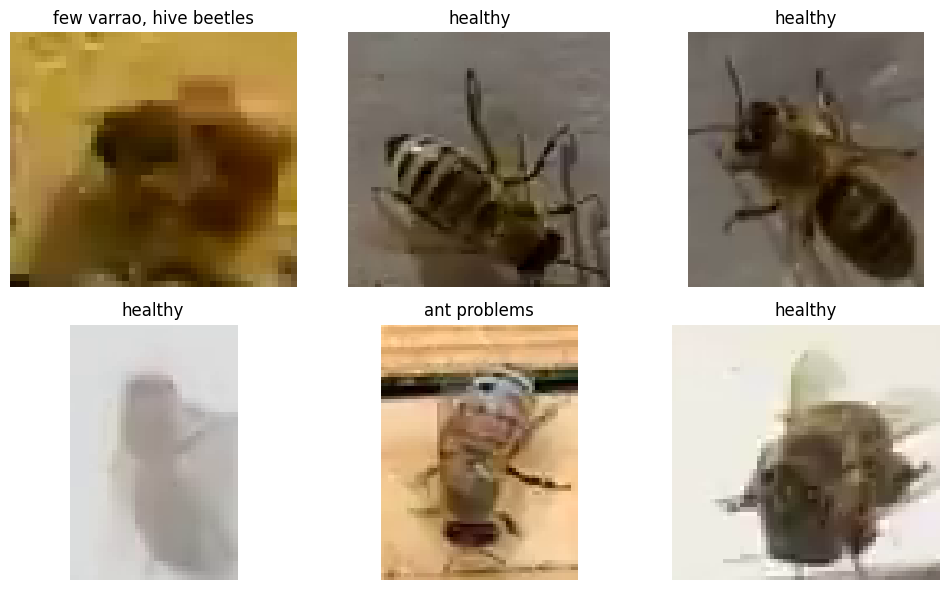

In [9]:
# Defined class names for reference
class_names = ["Varroa, Small Hive Beetles", "ant problems", "few varrao, hive beetles",
"healthy", "hive being robbed", "missing queen"]

# Plot a 2x3 grid of random images from the dataset along with their labels
plt.figure(figsize=(10, 6))
for i in range(6):
    index = np.random.randint(0, len(x_train_images))
    plt.subplot(2, 3, i + 1)
    plt.imshow(x_train_images[index])
    plt.title(y_train.iloc[index])
    plt.axis("off")
plt.tight_layout()
plt.show()

In [10]:
# 1. Preprocess images
# - resize
# - normalize pixel values
# - convert list to numpy array for the training
IMG_SIZE = 128
x_train_processed = np.array([
    np.array(Image.open(os.path.join("../bee_imgs", x_train.iloc[i, 0])).convert('RGB').resize((IMG_SIZE, IMG_SIZE))) / 255.0
    for i in range(len(x_train))
])

# Do the same for test images
x_test_images = [load_image(x_test.iloc[i, 0]) for i in range(len(x_test))]
x_test_processed = np.array([
    np.array(Image.open(os.path.join("../bee_imgs", x_test.iloc[i, 0])).convert('RGB').resize((IMG_SIZE, IMG_SIZE))) / 255.0
    for i in range(len(x_test))
])

# .convert('RGB') ensures all images are converted to 3-channel RGB format
# ensures all processed images have the ame shape (128, 128, 3) -> makes it possible for numpy to handle properly



In [11]:
# 2. Encode labels (y_train contains text labels, which NNs can use)

label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# Convert to one-hot encoding for neural network
y_train_categorical = to_categorical(y_train_encoded, num_classes)
y_test_categorical = to_categorical(y_test_encoded, num_classes)

print(f"x_train_processed shape: {x_train_processed.shape}")
print(f"y_train_categorical shape: {y_train_categorical.shape}")

x_train_processed shape: (4137, 128, 128, 3)
y_train_categorical shape: (4137, 6)


In [12]:
# 3. Build and Train the most basic CNN model (RandomForest and SVM will be added later)

# MODEL 1: Bare Minimum CNN
# Just one conv layer, one pooling, flatten, and output
model_basic = Sequential([
    Conv2D(16, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(num_classes, activation='softmax')
], name='basic_cnn')

model_basic.compile(optimizer='adam',
                    loss='categorical_crossentropy',
                    metrics=['accuracy'])

print("=" * 50)
print("MODEL 1: Basic CNN")
print("=" * 50)
model_basic.summary()

c:\Users\palag\Documents\Egyetem\THESIS\beeproject-cnn\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


MODEL 1: Basic CNN


Model: "basic_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 63504)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │       381,030 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 381,478 (1.46 MB)

 Trainable params: 381,478 (1.46 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# 4. Train the basic model
print("\nTraining the basic CNN model...")

history = model_basic.fit(
    x_train_processed, y_train_categorical,
    epochs=20,
    validation_split=0.2,  # Use 20% of training data for validation
    batch_size=32,
    verbose=1
)

# 5. Evaluate on test set
print("\nEvaluating on test set...")
test_loss, test_accuracy = model_basic.evaluate(x_test_processed, y_test_categorical)
print(f"\nTest Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")


Training the basic CNN model...
Epoch 1/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.7123 - loss: 0.9107 - val_accuracy: 0.8200 - val_loss: 0.4758
Epoch 2/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.8426 - loss: 0.3835 - val_accuracy: 0.8587 - val_loss: 0.3536
Epoch 3/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9024 - loss: 0.2568 - val_accuracy: 0.8527 - val_loss: 0.3252
Epoch 4/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9226 - loss: 0.2086 - val_accuracy: 0.8841 - val_loss: 0.2993
Epoch 5/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9435 - loss: 0.1607 - val_accuracy: 0.8829 - val_loss: 0.2688
Epoch 6/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9580 - loss: 0.1271 - val_accuracy: 0.9058 - val_loss: 0.2586
Epoch 7/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9662 - loss: 0.1075 - val_accuracy: 0.8937 - val_loss: 0.2541
Epoch 8/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy:

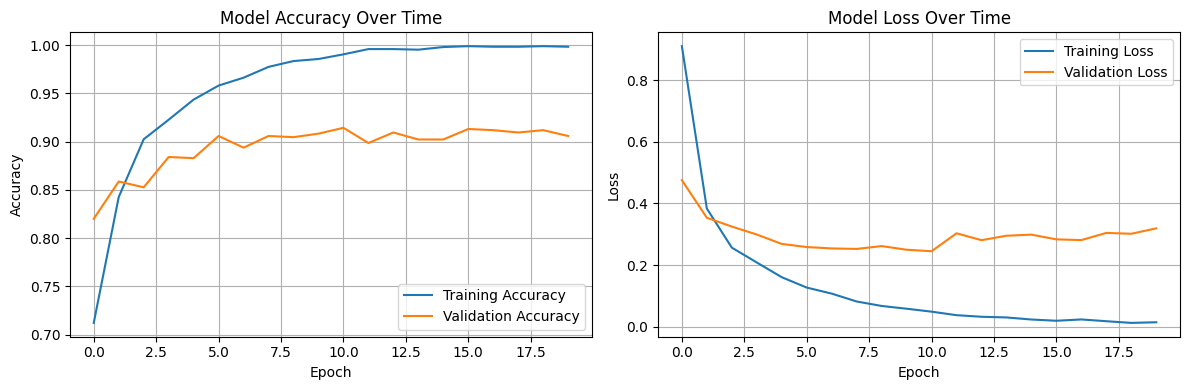

In [14]:
# 6. Plot training history
plt.figure(figsize=(12, 4))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy Over Time')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Time')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


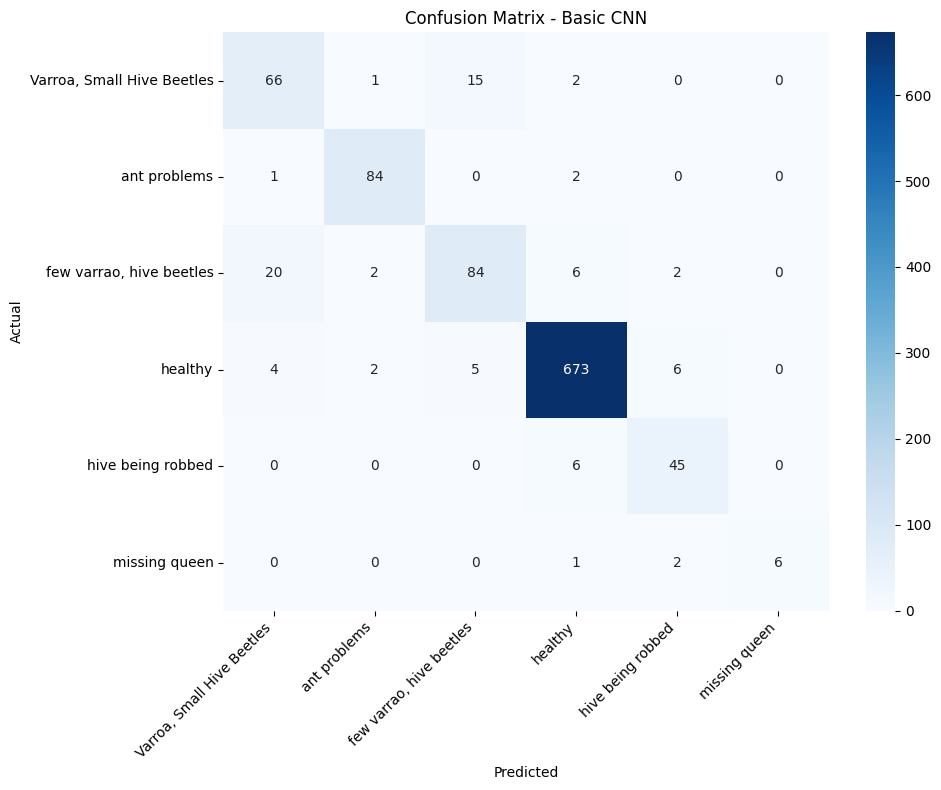


Classification Report:
                            precision    recall  f1-score   support

Varroa, Small Hive Beetles       0.73      0.79      0.75        84
              ant problems       0.94      0.97      0.95        87
  few varrao, hive beetles       0.81      0.74      0.77       114
                   healthy       0.98      0.98      0.98       690
         hive being robbed       0.82      0.88      0.85        51
             missing queen       1.00      0.67      0.80         9

                  accuracy                           0.93      1035
                 macro avg       0.88      0.84      0.85      1035
              weighted avg       0.93      0.93      0.93      1035



In [15]:
# 7. Make predictions and show confusion matrix

# Get predictions
y_pred = model_basic.predict(x_test_processed)
y_pred_classes = np.argmax(y_pred, axis=1)
y_test_classes = np.argmax(y_test_categorical, axis=1)

# Confusion matrix
cm = confusion_matrix(y_test_classes, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, 
            yticklabels=class_names)
plt.title('Confusion Matrix - Basic CNN')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Classification report
print("\nClassification Report:")
# Get unique labels that appear in the predictions
unique_labels = np.unique(np.concatenate([y_test_classes, y_pred_classes]))
unique_class_names = [class_names[i] for i in unique_labels]
print(classification_report(y_test_classes, y_pred_classes, 
                          labels=unique_labels,
                          target_names=unique_class_names))